In [1]:
import pandas as pd

retail = pd.read_csv("data\online_retail_II.csv")
retail 

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [2]:
retail = retail[pd.notnull(retail['Customer ID'])]

In [3]:
retail[retail['Quantity']<=0]
#18744 rows × 8 columns

retail = retail[retail['Quantity'] >= 1]

In [4]:
retail[retail['Price'] <= 0]
#71 rows × 8 columns

retail = retail[retail['Price'] > 0]

In [5]:
retail['CheckoutPrice'] = retail['Quantity'] * retail['Price']

retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Invoice        805549 non-null  object 
 1   StockCode      805549 non-null  object 
 2   Description    805549 non-null  object 
 3   Quantity       805549 non-null  int64  
 4   InvoiceDate    805549 non-null  object 
 5   Price          805549 non-null  float64
 6   Customer ID    805549 non-null  float64
 7   Country        805549 non-null  object 
 8   CheckoutPrice  805549 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 61.5+ MB


In [6]:
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Invoice        805549 non-null  object        
 1   StockCode      805549 non-null  object        
 2   Description    805549 non-null  object        
 3   Quantity       805549 non-null  int64         
 4   InvoiceDate    805549 non-null  datetime64[ns]
 5   Price          805549 non-null  float64       
 6   Customer ID    805549 non-null  float64       
 7   Country        805549 non-null  object        
 8   CheckoutPrice  805549 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 61.5+ MB


In [7]:
total_revenue = retail['CheckoutPrice'].sum()
total_revenue


np.float64(17743429.178000003)

In [8]:
retail['Country'].value_counts()

Country
United Kingdom          725250
Germany                  16694
EIRE                     15743
France                   13812
Netherlands               5088
Spain                     3719
Belgium                   3068
Switzerland               3011
Portugal                  2446
Australia                 1812
Channel Islands           1569
Italy                     1468
Norway                    1436
Sweden                    1319
Cyprus                    1155
Finland                   1032
Austria                    922
Denmark                    798
Greece                     657
Unspecified                521
Poland                     512
Japan                      485
USA                        409
United Arab Emirates       383
Singapore                  339
Israel                     322
Malta                      282
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        122
Brazil                      94


In [9]:
rev_by_countries = retail.groupby('Country')['CheckoutPrice'].sum().sort_values()
rev_by_countries

Country
Nigeria                 1.403900e+02
Saudi Arabia            1.459200e+02
West Indies             5.364100e+02
Czech Republic          8.267400e+02
Korea                   1.118510e+03
European Community      1.300250e+03
Bahrain                 1.354370e+03
Brazil                  1.411870e+03
Lebanon                 1.693880e+03
RSA                     1.933740e+03
Thailand                3.070540e+03
Canada                  4.883040e+03
Iceland                 5.633320e+03
Lithuania               6.553740e+03
Malta                   8.099090e+03
USA                     8.366860e+03
Unspecified             8.613650e+03
United Arab Emirates    9.202690e+03
Israel                  1.042109e+04
Poland                  1.090245e+04
Greece                  1.909619e+04
Austria                 2.361301e+04
Cyprus                  2.498013e+04
Singapore               2.531706e+04
Finland                 2.992554e+04
Italy                   3.255042e+04
Channel Islands         4.4996

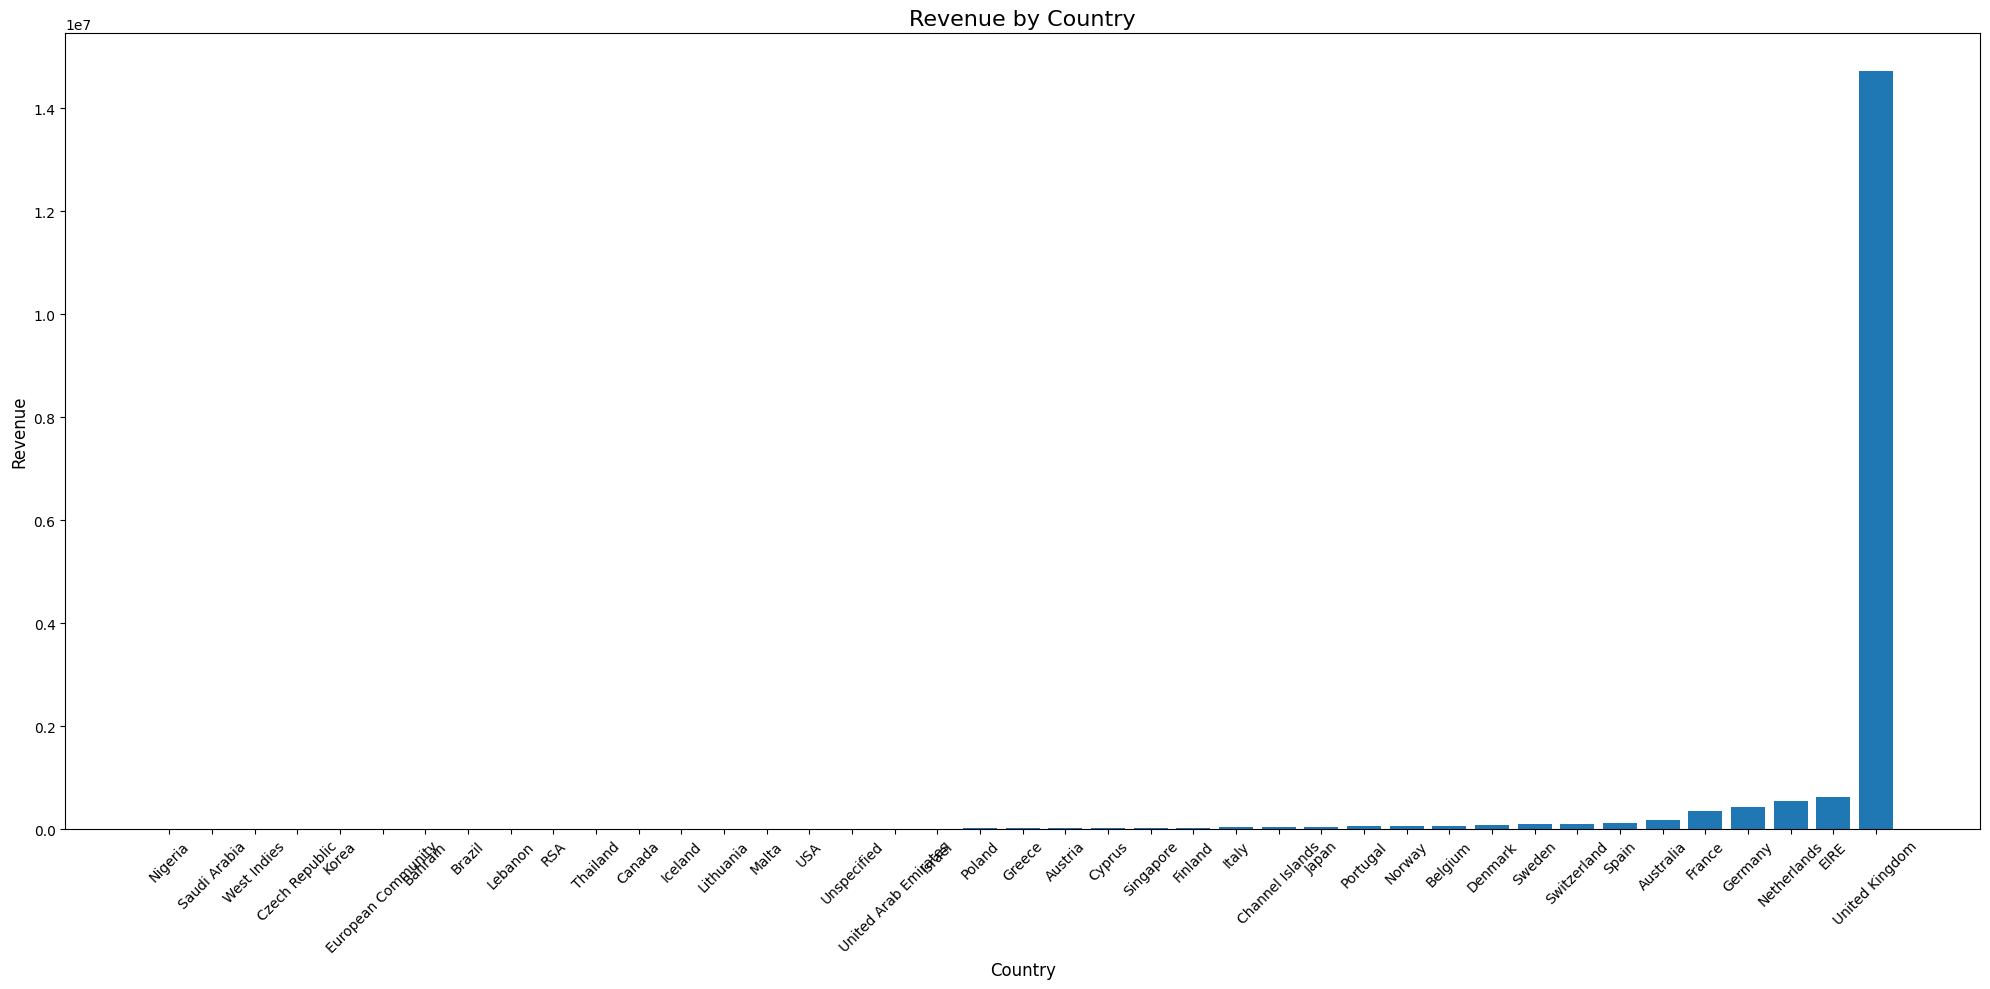

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (20, 10))
                      
ax.bar(rev_by_countries.index, rev_by_countries.values)

ax.set_xlabel('Country', fontsize = 12)
ax.set_ylabel('Revenue', fontsize = 12)
ax.set_title('Revenue by Country', fontsize = 16)

ax.set_xticks(range(len(rev_by_countries.index)))
ax.set_xticklabels(rev_by_countries.index, rotation = 45)

plt.tight_layout()
plt.show()

In [13]:
rev_by_countries/total_revenue

Country
Nigeria                 0.000008
Saudi Arabia            0.000008
West Indies             0.000030
Czech Republic          0.000047
Korea                   0.000063
European Community      0.000073
Bahrain                 0.000076
Brazil                  0.000080
Lebanon                 0.000095
RSA                     0.000109
Thailand                0.000173
Canada                  0.000275
Iceland                 0.000317
Lithuania               0.000369
Malta                   0.000456
USA                     0.000472
Unspecified             0.000485
United Arab Emirates    0.000519
Israel                  0.000587
Poland                  0.000614
Greece                  0.001076
Austria                 0.001331
Cyprus                  0.001408
Singapore               0.001427
Finland                 0.001687
Italy                   0.001835
Channel Islands         0.002536
Japan                   0.002657
Portugal                0.003229
Norway                  0.003388
Be

In [14]:
retail['InvoiceDate'].sort_values(ascending=False)


1067370   2011-12-09 12:50:00
1067362   2011-12-09 12:50:00
1067355   2011-12-09 12:50:00
1067357   2011-12-09 12:50:00
1067358   2011-12-09 12:50:00
                  ...        
5         2009-12-01 07:45:00
4         2009-12-01 07:45:00
3         2009-12-01 07:45:00
2         2009-12-01 07:45:00
0         2009-12-01 07:45:00
Name: InvoiceDate, Length: 805549, dtype: datetime64[ns]

In [15]:
def extract_month(date):
    month = str(date.month)
    if(date.month < 10):
        month = '0' + month #두자리수 월 만들기
    return str(date.year) + month

In [16]:
rev_by_month = retail.set_index('InvoiceDate').groupby(extract_month)['CheckoutPrice'].sum()

In [17]:
def plot_bar(df, xlabel, ylabel, title, figsize=(20, 10), fontsize=12, titlesize=15, rotation=45):
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(df.index, df.values)
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_title(title, fontsize=titlesize)
    ax.set_xticks(df.index)
    ax.set_xticklabels(df.index, rotation=rotation, fontsize=fontsize)
    plt.tight_layout()
    plt.show()

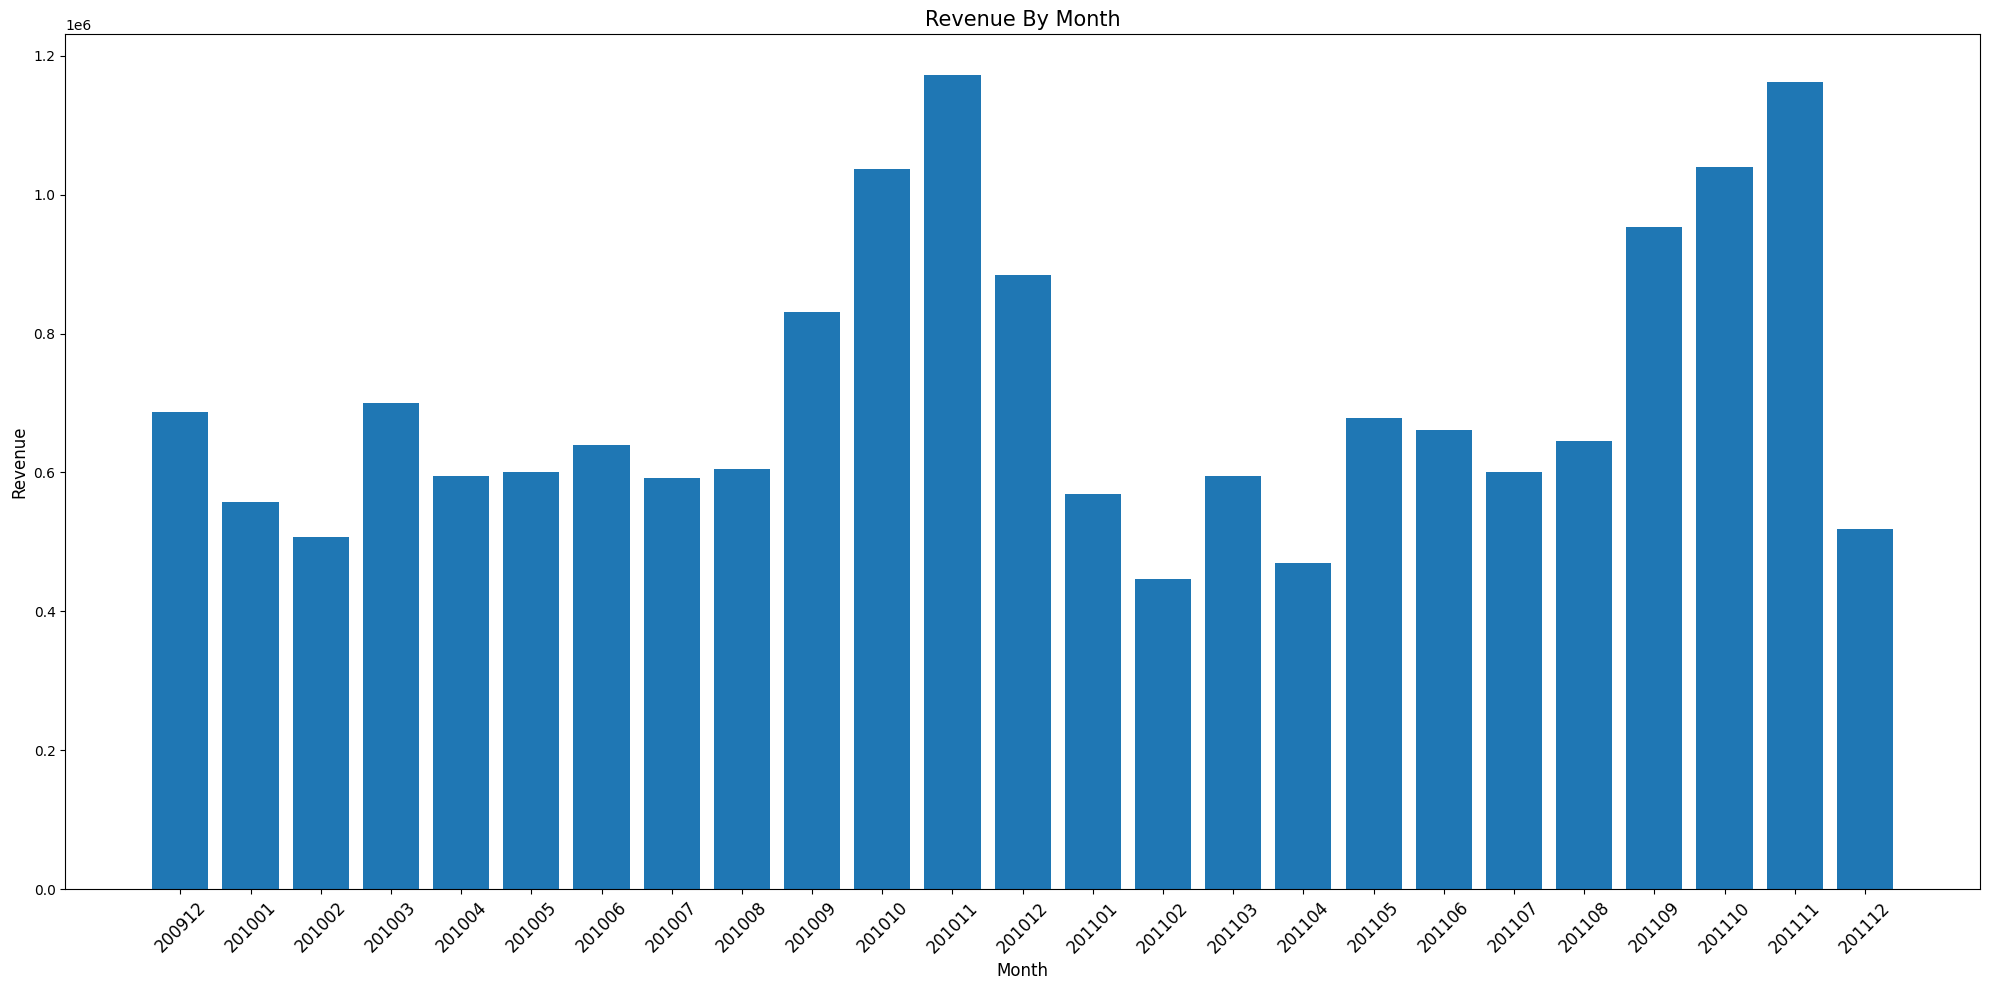

In [18]:
plot_bar(rev_by_month, 'Month', 'Revenue', 'Revenue By Month')

In [ ]:
# 요일별 매출 구하기
def extract_dow(date):
    return date.dayofweek

rev_by_dow = retail.set_index('InvoiceDate').groupby(lambda date: date.dayofweek)['CheckoutPrice'].sum()
rev_by_dow

# InvoiceDate
# 0    2817407.806
# 1    3384678.832
# 2    3115619.693
# 3    3841082.962
# 4    2758423.493
# 5       9803.050
# 6    1816413.342
# Name: CheckoutPrice, dtype: float64

InvoiceDate
0    2817407.806
1    3384678.832
2    3115619.693
3    3841082.962
4    2758423.493
5       9803.050
6    1816413.342
Name: CheckoutPrice, dtype: float64

In [ ]:
import numpy as np

DAY_OF_WEEK = np.array(['Mon', 'Tue', 'Web', 'Thur', 'Fri', 'Sat', 'Sun'])
rev_by_dow.index = DAY_OF_WEEK[rev_by_dow.index]
rev_by_dow.index

#Index(['Mon', 'Tue', 'Web', 'Thur', 'Fri', 'Sat', 'Sun'], dtype='object')

Index(['Mon', 'Tue', 'Web', 'Thur', 'Fri', 'Sat', 'Sun'], dtype='object')

In [21]:
rev_by_dow

Mon     2817407.806
Tue     3384678.832
Web     3115619.693
Thur    3841082.962
Fri     2758423.493
Sat        9803.050
Sun     1816413.342
Name: CheckoutPrice, dtype: float64

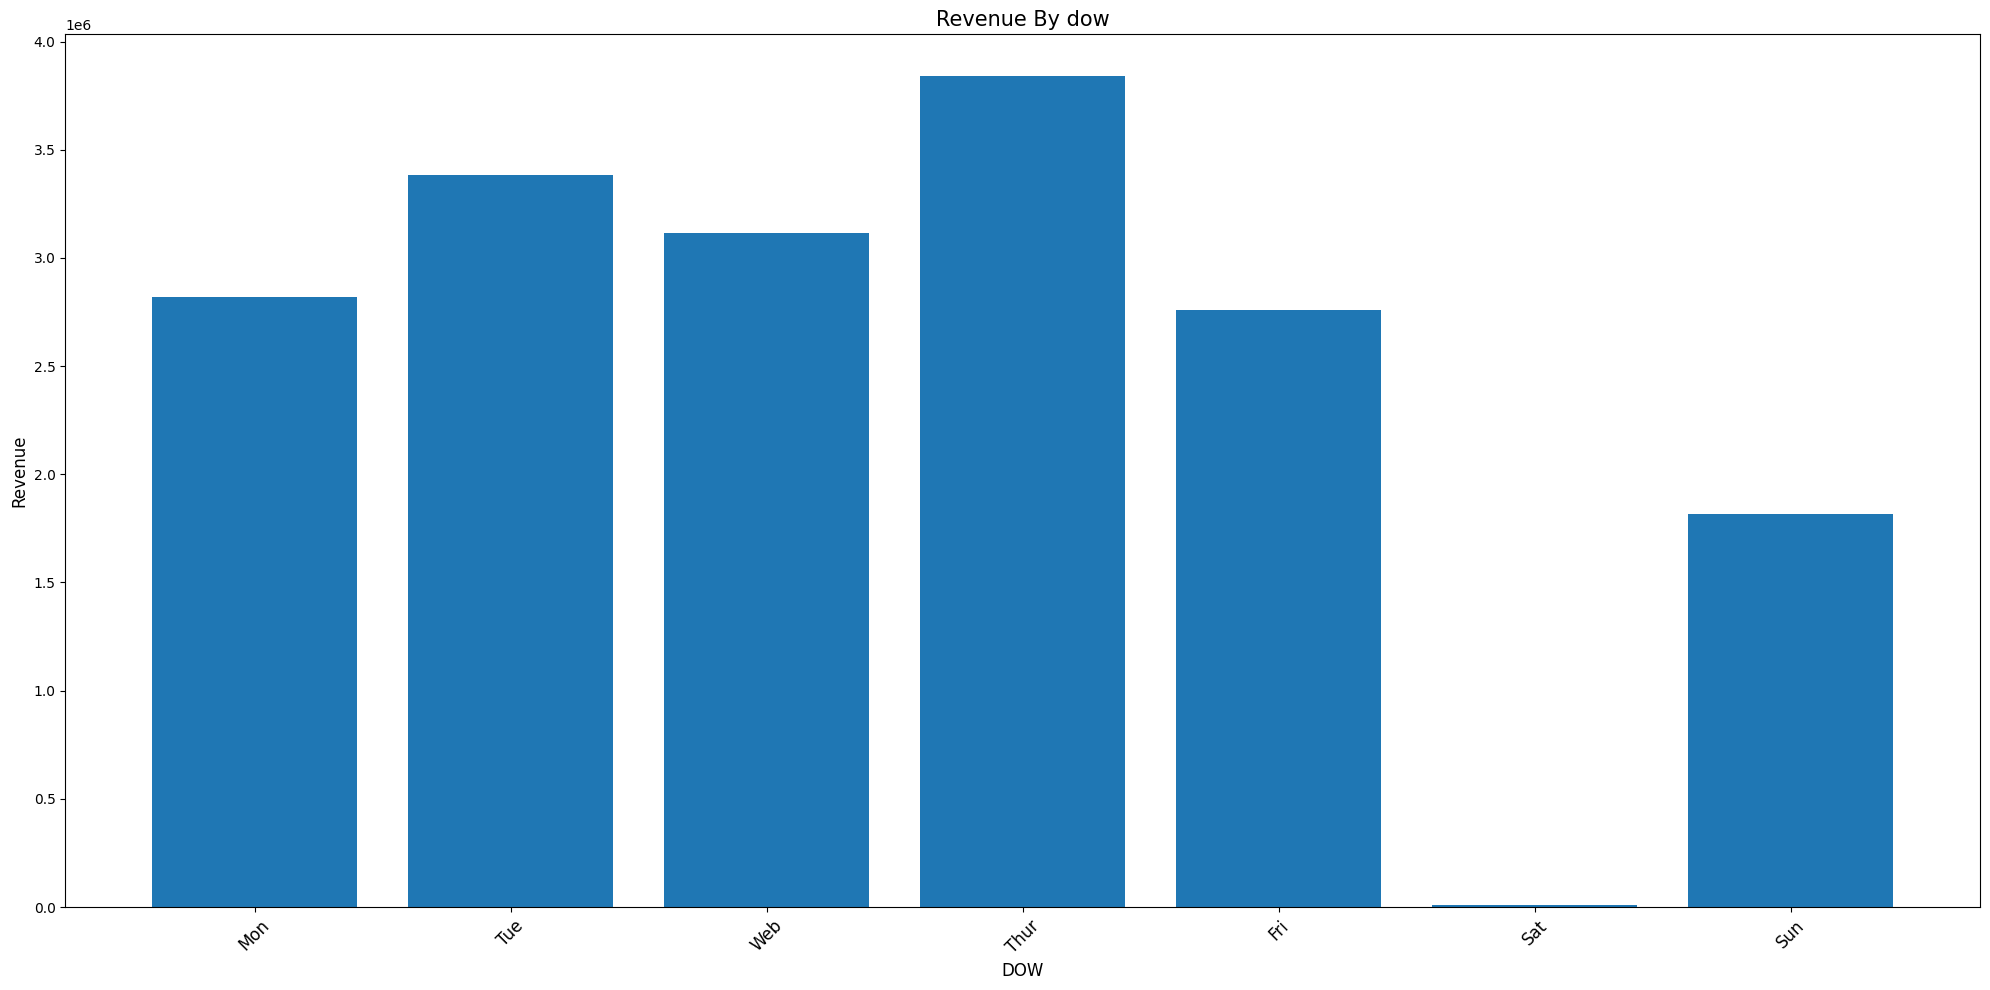

In [25]:
plot_bar(rev_by_dow, 'DOW', 'Revenue','Revenue By dow')

In [23]:
rev_by_hour = retail.set_index('InvoiceDate').groupby(lambda date: date.hour)['CheckoutPrice'].sum()
rev_by_hour

InvoiceDate
6           4.250
7       76212.570
8      528877.660
9     1509659.881
10    2360784.823
11    2271810.993
12    2750224.631
13    2401116.924
14    1995849.271
15    1882943.792
16    1109616.461
17     495200.732
18     194533.670
19     126979.280
20      39614.240
Name: CheckoutPrice, dtype: float64

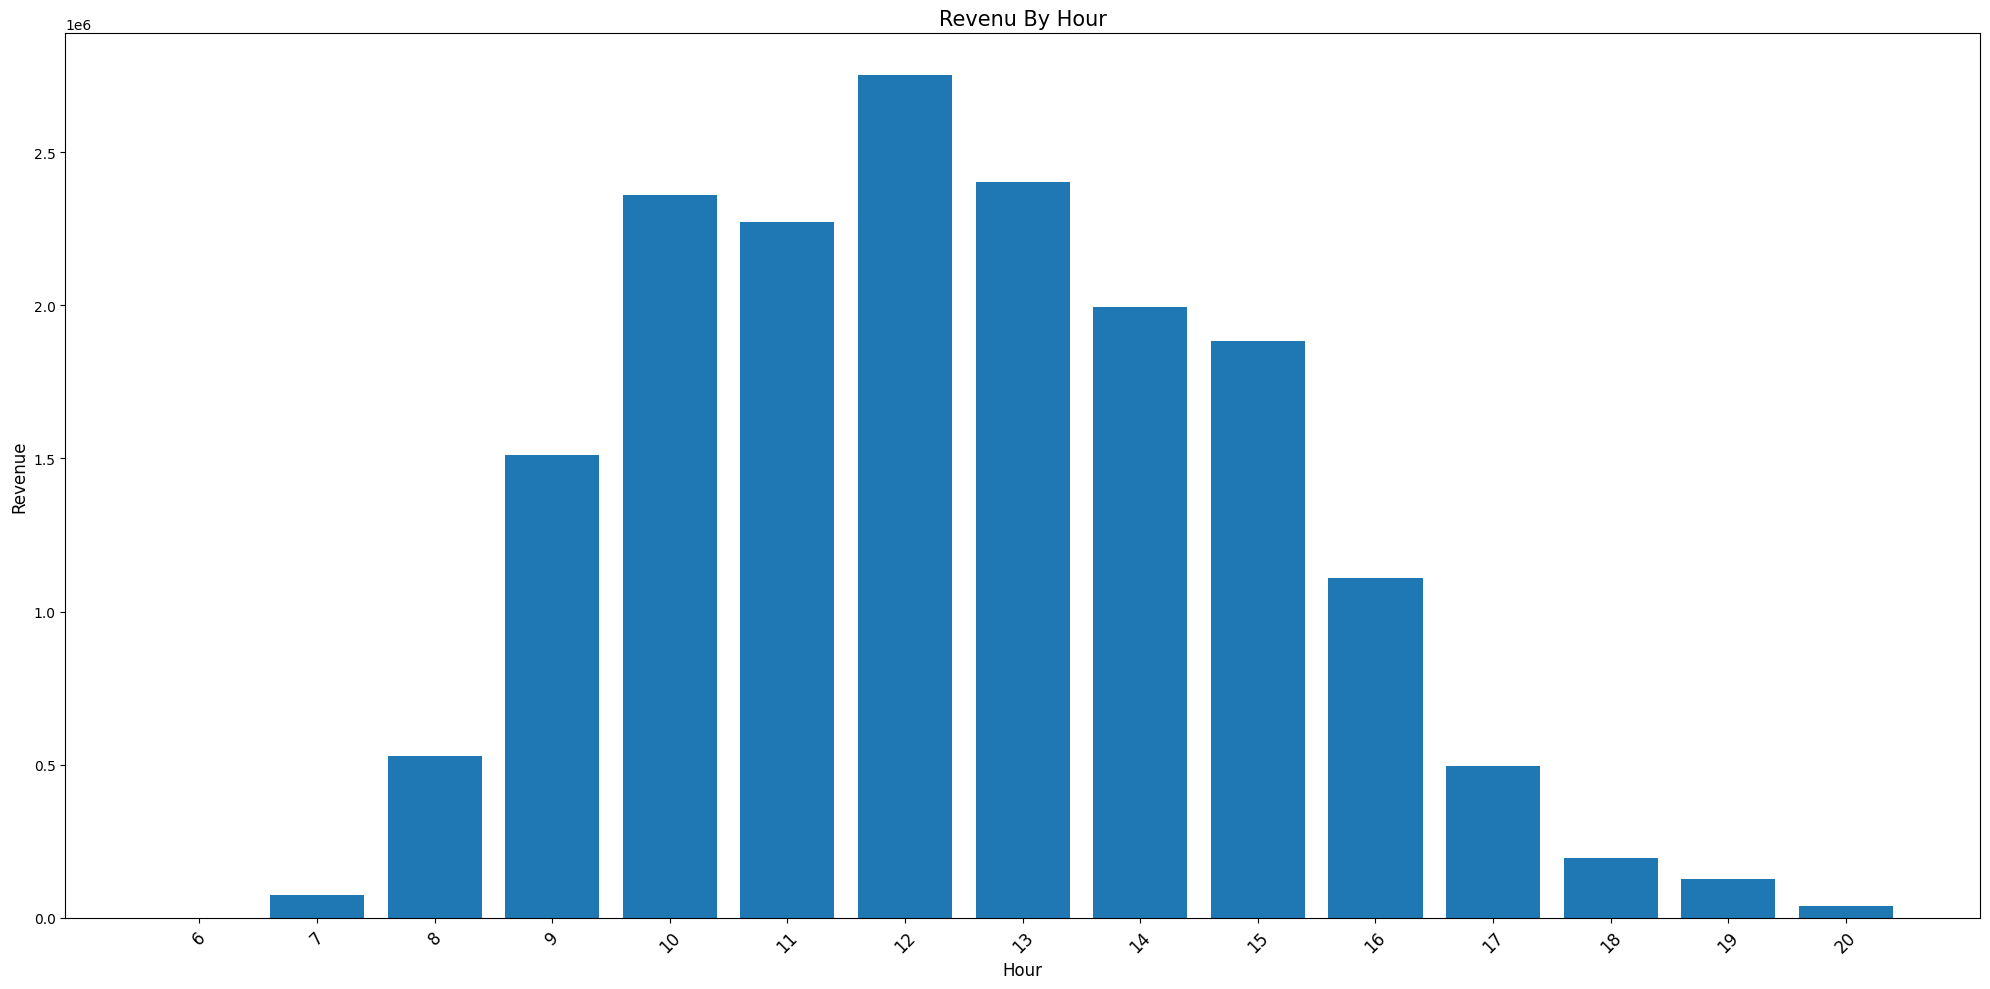

In [24]:
plot_bar(rev_by_hour, 'Hour', 'Revenue', 'Revenu By Hour')